In [ ]:
from io import StringIO
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

from pylib import allele_palette, strain_palette

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-18T05:13:33.992921+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
seaborn   : 0.13.2
marimo    : 0.23.2
pandas    : 2.2.3
matplotlib: 3.10.7

```

## Data

Hardcoded copy of `BasicTable2.xlsx` (basic 2-site model from the
paper, attached to issue #20). Each `J{ab}:1` column is the
population-fraction prevalence of the strain with site-0 allele `a`
(in `{0, 1}`) and site-1 allele `b` (in `{2, 3}`); columns have been
reordered so that strain labels read 00, 01, 10, 11 left to right.

In [ ]:
BASICTABLE2_CSV = """\
TIME,J02:1,J03:1,J12:1,J13:1
0,1e-05,0,0,0
1,1.221e-05,0,0,0
2,1.491e-05,0,0,0
3,1.822e-05,0,0,0
4,2.225e-05,0,0,0
5,2.717e-05,0,0,0
6,3.318e-05,0,0,0
7,4.052e-05,0,0,0
8,4.948e-05,0,0,0
9,6.043e-05,0,0,0
10,7.38e-05,0,0,0
11,9.013e-05,0,0,0
12,0.00011007,0,0,0
13,0.00013441,1e-08,1e-08,0
14,0.00016415,1e-08,1e-08,0
15,0.00020045,1e-08,1e-08,0
16,0.00024478,1e-08,1e-08,0
17,0.00029891,2e-08,2e-08,0
18,0.000365,2e-08,2e-08,0
19,0.00044568,3e-08,3e-08,0
20,0.00054418,3e-08,3e-08,0
21,0.00066442,4e-08,4e-08,0
22,0.00081117,5e-08,5e-08,0
23,0.00099028,7e-08,7e-08,0
24,0.00120882,9e-08,9e-08,0
25,0.00147543,1.1e-07,1.1e-07,0
26,0.00180062,1.4e-07,1.4e-07,0
27,0.00219714,1.8e-07,1.8e-07,0
28,0.00268045,2.3e-07,2.3e-07,0
29,0.00326932,2.8e-07,2.8e-07,0
30,0.00398643,3.6e-07,3.6e-07,0
31,0.00485914,4.5e-07,4.5e-07,0
32,0.00592041,5.7e-07,5.7e-07,0
33,0.00720976,7.1e-07,7.1e-07,0
34,0.00877443,8.9e-07,8.9e-07,0
35,0.0106706,1.12e-06,1.12e-06,0
36,0.0129646,1.4e-06,1.4e-06,0
37,0.0157342,1.74e-06,1.74e-06,0
38,0.01907,2.17e-06,2.17e-06,0
39,0.0230755,2.7e-06,2.7e-06,0
40,0.027868,3.34e-06,3.34e-06,0
41,0.0335776,4.12e-06,4.12e-06,0
42,0.0403445,5.08e-06,5.08e-06,0
43,0.0483152,6.22e-06,6.22e-06,0
44,0.0576352,7.6e-06,7.6e-06,0
45,0.068439,9.23e-06,9.23e-06,0
46,0.0808359,1.114e-05,1.114e-05,0
47,0.0948928,1.337e-05,1.337e-05,0
48,0.110614,1.592e-05,1.592e-05,0
49,0.127922,1.88e-05,1.88e-05,0
50,0.146638,2.201e-05,2.201e-05,0
51,0.166468,2.552e-05,2.552e-05,0
52,0.187009,2.928e-05,2.928e-05,1e-08
53,0.207757,3.322e-05,3.322e-05,1e-08
54,0.228135,3.727e-05,3.727e-05,1e-08
55,0.247541,4.133e-05,4.133e-05,1e-08
56,0.265388,4.531e-05,4.531e-05,1e-08
57,0.28116,4.913e-05,4.913e-05,1e-08
58,0.294449,5.269e-05,5.269e-05,1e-08
59,0.304981,5.594e-05,5.594e-05,1e-08
60,0.312624,5.883e-05,5.883e-05,2e-08
61,0.317381,6.136e-05,6.136e-05,2e-08
62,0.319371,6.35e-05,6.35e-05,2e-08
63,0.318804,6.527e-05,6.527e-05,2e-08
64,0.315949,6.67e-05,6.67e-05,2e-08
65,0.311108,6.781e-05,6.781e-05,3e-08
66,0.304596,6.864e-05,6.864e-05,3e-08
67,0.296721,6.921e-05,6.921e-05,3e-08
68,0.287772,6.958e-05,6.958e-05,4e-08
69,0.27801,6.977e-05,6.977e-05,4e-08
70,0.267669,6.981e-05,6.981e-05,5e-08
71,0.256948,6.972e-05,6.972e-05,5e-08
72,0.246018,6.954e-05,6.954e-05,6e-08
73,0.23502,6.928e-05,6.928e-05,7e-08
74,0.224071,6.896e-05,6.896e-05,8e-08
75,0.213264,6.859e-05,6.859e-05,9e-08
76,0.202672,6.818e-05,6.818e-05,1.1e-07
77,0.192353,6.776e-05,6.776e-05,1.2e-07
78,0.182348,6.732e-05,6.732e-05,1.4e-07
79,0.172688,6.687e-05,6.687e-05,1.6e-07
80,0.163395,6.641e-05,6.641e-05,1.9e-07
81,0.154481,6.596e-05,6.596e-05,2.2e-07
82,0.145954,6.551e-05,6.551e-05,2.6e-07
83,0.137813,6.507e-05,6.507e-05,3e-07
84,0.130057,6.463e-05,6.463e-05,3.5e-07
85,0.122681,6.421e-05,6.421e-05,4.2e-07
86,0.115674,6.38e-05,6.38e-05,4.9e-07
87,0.109028,6.34e-05,6.34e-05,5.8e-07
88,0.10273,6.302e-05,6.302e-05,6.9e-07
89,0.0967686,6.265e-05,6.265e-05,8.1e-07
90,0.0911301,6.229e-05,6.229e-05,9.7e-07
91,0.085801,6.194e-05,6.194e-05,1.15e-06
92,0.0807677,6.161e-05,6.161e-05,1.37e-06
93,0.0760166,6.13e-05,6.13e-05,1.63e-06
94,0.0715341,6.099e-05,6.099e-05,1.95e-06
95,0.0673069,6.07e-05,6.07e-05,2.33e-06
96,0.0633222,6.043e-05,6.043e-05,2.79e-06
97,0.0595675,6.016e-05,6.016e-05,3.35e-06
98,0.0560305,5.991e-05,5.991e-05,4.02e-06
99,0.0526995,5.967e-05,5.967e-05,4.83e-06
100,0.0495635,5.944e-05,5.944e-05,5.81e-06
101,0.0466116,5.922e-05,5.922e-05,6.99e-06
102,0.0438336,5.901e-05,5.901e-05,8.42e-06
103,0.0412196,5.881e-05,5.881e-05,1.015e-05
104,0.0387605,5.862e-05,5.862e-05,1.225e-05
105,0.0364474,5.845e-05,5.845e-05,1.479e-05
106,0.0342717,5.828e-05,5.828e-05,1.787e-05
107,0.0322257,5.812e-05,5.812e-05,2.16e-05
108,0.0303018,5.797e-05,5.797e-05,2.613e-05
109,0.0284928,5.783e-05,5.783e-05,3.162e-05
110,0.026792,5.77e-05,5.77e-05,3.83e-05
111,0.025193,5.758e-05,5.758e-05,4.64e-05
112,0.0236898,5.746e-05,5.746e-05,5.624e-05
113,0.0222767,5.735e-05,5.735e-05,6.82e-05
114,0.0209484,5.725e-05,5.725e-05,8.273e-05
115,0.0196998,5.716e-05,5.716e-05,0.0001004
116,0.0185262,5.708e-05,5.708e-05,0.00012188
117,0.0174231,5.7e-05,5.7e-05,0.00014802
118,0.0163862,5.693e-05,5.693e-05,0.0001798
119,0.0154116,5.687e-05,5.687e-05,0.00021848
120,0.0144956,5.681e-05,5.681e-05,0.00026555
121,0.0136345,5.676e-05,5.676e-05,0.00032283
122,0.0128252,5.672e-05,5.672e-05,0.00039256
123,0.0120645,5.669e-05,5.669e-05,0.00047745
124,0.0113494,5.666e-05,5.666e-05,0.00058079
125,0.0106772,5.663e-05,5.663e-05,0.00070661
126,0.0100453,5.662e-05,5.662e-05,0.00085981
127,0.00945128,5.66e-05,5.66e-05,0.00104633
128,0.00889283,5.66e-05,5.66e-05,0.00127341
129,0.00836779,5.659e-05,5.659e-05,0.00154985
130,0.00787414,5.66e-05,5.66e-05,0.00188633
131,0.00740997,5.66e-05,5.66e-05,0.00229582
132,0.00697348,5.661e-05,5.661e-05,0.00279402
133,0.006563,5.663e-05,5.663e-05,0.00339993
134,0.00617693,5.664e-05,5.664e-05,0.0041365
135,0.00581378,5.665e-05,5.665e-05,0.00503141
136,0.00547215,5.667e-05,5.667e-05,0.0061179
137,0.00515071,5.668e-05,5.668e-05,0.00743582
138,0.00484822,5.669e-05,5.669e-05,0.00903269
139,0.00456352,5.669e-05,5.669e-05,0.0109649
140,0.00429548,5.668e-05,5.668e-05,0.0132991
141,0.00404308,5.666e-05,5.666e-05,0.0161132
142,0.00380532,5.662e-05,5.662e-05,0.0194974
143,0.00358129,5.656e-05,5.656e-05,0.0235553
144,0.0033701,5.647e-05,5.647e-05,0.0284033
145,0.00317094,5.635e-05,5.635e-05,0.0341703
146,0.00298302,5.618e-05,5.618e-05,0.040995
147,0.00280562,5.597e-05,5.597e-05,0.0490215
148,0.00263805,5.569e-05,5.569e-05,0.0583922
149,0.00247966,5.535e-05,5.535e-05,0.0692375
150,0.00232986,5.492e-05,5.492e-05,0.081662
151,0.0021881,5.44e-05,5.44e-05,0.0957271
152,0.00205386,5.377e-05,5.377e-05,0.111432
153,0.00192671,5.302e-05,5.302e-05,0.128693
154,0.00180623,5.215e-05,5.215e-05,0.147326
155,0.00169207,5.114e-05,5.114e-05,0.167038
156,0.00158392,5e-05,5e-05,0.187425
157,0.00148153,4.873e-05,4.873e-05,0.207986
158,0.00138468,4.732e-05,4.732e-05,0.228154
159,0.00129319,4.579e-05,4.579e-05,0.247333
160,0.00120689,4.416e-05,4.416e-05,0.26495
161,0.00112564,4.244e-05,4.244e-05,0.280502
162,0.00104929,4.065e-05,4.065e-05,0.293591
163,0.00097769,3.881e-05,3.881e-05,0.303951
164,0.00091069,3.695e-05,3.695e-05,0.311455
165,0.00084811,3.509e-05,3.509e-05,0.316111
166,0.00078976,3.324e-05,3.324e-05,0.318036
167,0.00073545,3.142e-05,3.142e-05,0.317438
168,0.00068496,2.964e-05,2.964e-05,0.314581
169,0.00063807,2.793e-05,2.793e-05,0.309765
170,0.00059457,2.627e-05,2.627e-05,0.303297
171,0.00055423,2.469e-05,2.469e-05,0.295482
172,0.00051685,2.317e-05,2.317e-05,0.286602
173,0.0004822,2.174e-05,2.174e-05,0.276918
174,0.00045009,2.038e-05,2.038e-05,0.266658
175,0.00042034,1.909e-05,1.909e-05,0.256019
176,0.00039276,1.788e-05,1.788e-05,0.245171
177,0.00036718,1.674e-05,1.674e-05,0.234253
178,0.00034345,1.567e-05,1.567e-05,0.223381
179,0.00032143,1.467e-05,1.467e-05,0.212646
180,0.00030098,1.372e-05,1.372e-05,0.202122
181,0.00028198,1.284e-05,1.284e-05,0.191866
182,0.00026431,1.202e-05,1.202e-05,0.18192
183,0.00024787,1.124e-05,1.124e-05,0.172315
184,0.00023257,1.052e-05,1.052e-05,0.163071
185,0.00021832,9.85e-06,9.85e-06,0.154202
186,0.00020503,9.21e-06,9.21e-06,0.145716
187,0.00019264,8.62e-06,8.62e-06,0.137613
188,0.00018108,8.07e-06,8.07e-06,0.12989
189,0.00017028,7.56e-06,7.56e-06,0.122544
190,0.00016019,7.08e-06,7.08e-06,0.115564
191,0.00015076,6.63e-06,6.63e-06,0.108942
192,0.00014193,6.21e-06,6.21e-06,0.102666
193,0.00013367,5.81e-06,5.81e-06,0.0967235
194,0.00012594,5.44e-06,5.44e-06,0.0911019
195,0.00011869,5.1e-06,5.1e-06,0.0857877
196,0.0001119,4.78e-06,4.78e-06,0.0807675
197,0.00010553,4.48e-06,4.48e-06,0.0760279
198,9.955e-05,4.2e-06,4.2e-06,0.0715554
199,9.394e-05,3.94e-06,3.94e-06,0.0673369
200,8.867e-05,3.69e-06,3.69e-06,0.0633597
201,8.372e-05,3.46e-06,3.46e-06,0.0596113
202,7.907e-05,3.24e-06,3.24e-06,0.0560797
203,7.47e-05,3.04e-06,3.04e-06,0.0527533
204,7.058e-05,2.85e-06,2.85e-06,0.049621
205,6.671e-05,2.68e-06,2.68e-06,0.0466722
206,6.307e-05,2.51e-06,2.51e-06,0.0438966
207,5.964e-05,2.36e-06,2.36e-06,0.0412846
208,5.641e-05,2.21e-06,2.21e-06,0.0388269
209,5.337e-05,2.08e-06,2.08e-06,0.0365147
210,5.05e-05,1.95e-06,1.95e-06,0.0343397
211,4.78e-05,1.83e-06,1.83e-06,0.0322939
212,4.525e-05,1.72e-06,1.72e-06,0.03037
213,4.284e-05,1.62e-06,1.62e-06,0.0285607
214,4.057e-05,1.52e-06,1.52e-06,0.0268594
215,3.843e-05,1.43e-06,1.43e-06,0.0252597
216,3.641e-05,1.34e-06,1.34e-06,0.0237557
217,3.45e-05,1.26e-06,1.26e-06,0.0223416
218,3.27e-05,1.18e-06,1.18e-06,0.0210122
219,3.1e-05,1.11e-06,1.11e-06,0.0197625
220,2.939e-05,1.04e-06,1.04e-06,0.0185876
221,2.787e-05,9.8e-07,9.8e-07,0.0174831
222,2.644e-05,9.2e-07,9.2e-07,0.0164449
223,2.508e-05,8.7e-07,8.7e-07,0.0154689
224,2.379e-05,8.2e-07,8.2e-07,0.0145515
225,2.258e-05,7.7e-07,7.7e-07,0.013689
226,2.143e-05,7.2e-07,7.2e-07,0.0128783
227,2.034e-05,6.8e-07,6.8e-07,0.0121161
228,1.932e-05,6.4e-07,6.4e-07,0.0113996
229,1.834e-05,6e-07,6e-07,0.0107261
230,1.742e-05,5.7e-07,5.7e-07,0.0100929
231,1.655e-05,5.3e-07,5.3e-07,0.00949763
232,1.572e-05,5e-07,5e-07,0.00893798
233,1.494e-05,4.7e-07,4.7e-07,0.00841181
234,1.42e-05,4.5e-07,4.5e-07,0.0079171
235,1.35e-05,4.2e-07,4.2e-07,0.00745195
236,1.283e-05,4e-07,4e-07,0.00701459
237,1.22e-05,3.7e-07,3.7e-07,0.00660333
238,1.16e-05,3.5e-07,3.5e-07,0.0062166
239,1.104e-05,3.3e-07,3.3e-07,0.00585293
240,1.05e-05,3.1e-07,3.1e-07,0.00551092
241,9.99e-06,2.9e-07,2.9e-07,0.00518926
242,9.51e-06,2.8e-07,2.8e-07,0.00488674
243,9.05e-06,2.6e-07,2.6e-07,0.0046022
244,8.61e-06,2.5e-07,2.5e-07,0.00433455
245,8.2e-06,2.3e-07,2.3e-07,0.00408278
246,7.81e-06,2.2e-07,2.2e-07,0.00384593
247,7.44e-06,2.1e-07,2.1e-07,0.00362311
248,7.08e-06,1.9e-07,1.9e-07,0.00341347
249,6.75e-06,1.8e-07,1.8e-07,0.00321623
250,6.43e-06,1.7e-07,1.7e-07,0.00303063
251,6.13e-06,1.6e-07,1.6e-07,0.00285598
252,5.84e-06,1.5e-07,1.5e-07,0.00269162
253,5.57e-06,1.5e-07,1.5e-07,0.00253694
254,5.31e-06,1.4e-07,1.4e-07,0.00239135
255,5.06e-06,1.3e-07,1.3e-07,0.00225432
256,4.83e-06,1.2e-07,1.2e-07,0.00212532
257,4.6e-06,1.2e-07,1.2e-07,0.00200389
258,4.39e-06,1.1e-07,1.1e-07,0.00188956
259,4.19e-06,1e-07,1e-07,0.00178192
260,4e-06,1e-07,1e-07,0.00168057
261,3.82e-06,9e-08,9e-08,0.00158513
262,3.64e-06,9e-08,9e-08,0.00149525
263,3.48e-06,8e-08,8e-08,0.0014106
264,3.32e-06,8e-08,8e-08,0.00133087
265,3.17e-06,7e-08,7e-08,0.00125576
266,3.03e-06,7e-08,7e-08,0.00118502
267,2.9e-06,7e-08,7e-08,0.00111836
268,2.77e-06,6e-08,6e-08,0.00105556
269,2.64e-06,6e-08,6e-08,0.00099639
270,2.53e-06,6e-08,6e-08,0.00094063
271,2.42e-06,5e-08,5e-08,0.00088807
272,2.31e-06,5e-08,5e-08,0.00083854
273,2.21e-06,5e-08,5e-08,0.00079186
274,2.11e-06,4e-08,4e-08,0.00074785
275,2.02e-06,4e-08,4e-08,0.00070636
276,1.93e-06,4e-08,4e-08,0.00066724
277,1.85e-06,4e-08,4e-08,0.00063036
278,1.77e-06,4e-08,4e-08,0.00059558
279,1.7e-06,3e-08,3e-08,0.00056278
280,1.62e-06,3e-08,3e-08,0.00053184
281,1.55e-06,3e-08,3e-08,0.00050266
282,1.49e-06,3e-08,3e-08,0.00047513
283,1.43e-06,3e-08,3e-08,0.00044916
284,1.37e-06,3e-08,3e-08,0.00042465
285,1.31e-06,2e-08,2e-08,0.00040153
286,1.25e-06,2e-08,2e-08,0.00037971
287,1.2e-06,2e-08,2e-08,0.00035911
288,1.15e-06,2e-08,2e-08,0.00033967
289,1.11e-06,2e-08,2e-08,0.00032132
290,1.06e-06,2e-08,2e-08,0.000304
291,1.02e-06,2e-08,2e-08,0.00028765
292,9.8e-07,2e-08,2e-08,0.0002722
293,9.4e-07,2e-08,2e-08,0.00025762
294,9e-07,2e-08,2e-08,0.00024384
295,8.6e-07,1e-08,1e-08,0.00023083
296,8.3e-07,1e-08,1e-08,0.00021854
297,7.9e-07,1e-08,1e-08,0.00020693
298,7.6e-07,1e-08,1e-08,0.00019596
299,7.3e-07,1e-08,1e-08,0.00018559
300,7e-07,1e-08,1e-08,0.0001758
301,6.8e-07,1e-08,1e-08,0.00016654
302,6.5e-07,1e-08,1e-08,0.00015779
303,6.3e-07,1e-08,1e-08,0.00014951
304,6e-07,1e-08,1e-08,0.00014169
305,5.8e-07,1e-08,1e-08,0.0001343
306,5.6e-07,1e-08,1e-08,0.0001273
307,5.3e-07,1e-08,1e-08,0.00012069
308,5.1e-07,1e-08,1e-08,0.00011443
309,4.9e-07,1e-08,1e-08,0.00010851
310,4.8e-07,1e-08,1e-08,0.00010292
311,4.6e-07,1e-08,1e-08,9.762e-05
312,4.4e-07,1e-08,1e-08,9.261e-05
313,4.2e-07,1e-08,1e-08,8.786e-05
314,4.1e-07,1e-08,1e-08,8.337e-05
315,3.9e-07,1e-08,1e-08,7.912e-05
316,3.8e-07,1e-08,1e-08,7.51e-05
317,3.7e-07,0,0,7.129e-05
318,3.5e-07,0,0,6.768e-05
319,3.4e-07,0,0,6.427e-05
320,3.3e-07,0,0,6.103e-05
321,3.2e-07,0,0,5.797e-05
322,3e-07,0,0,5.506e-05
323,2.9e-07,0,0,5.231e-05
324,2.8e-07,0,0,4.971e-05
325,2.7e-07,0,0,4.724e-05
326,2.6e-07,0,0,4.49e-05
327,2.6e-07,0,0,4.268e-05
328,2.5e-07,0,0,4.057e-05
329,2.4e-07,0,0,3.858e-05
330,2.3e-07,0,0,3.669e-05
331,2.2e-07,0,0,3.489e-05
332,2.1e-07,0,0,3.319e-05
333,2.1e-07,0,0,3.158e-05
334,2e-07,0,0,3.005e-05
335,1.9e-07,0,0,2.859e-05
336,1.9e-07,0,0,2.722e-05
337,1.8e-07,0,0,2.591e-05
338,1.8e-07,0,0,2.466e-05
339,1.7e-07,0,0,2.349e-05
340,1.6e-07,0,0,2.237e-05
341,1.6e-07,0,0,2.13e-05
342,1.5e-07,0,0,2.029e-05
343,1.5e-07,0,0,1.934e-05
344,1.4e-07,0,0,1.842e-05
345,1.4e-07,0,0,1.756e-05
346,1.4e-07,0,0,1.674e-05
347,1.3e-07,0,0,1.596e-05
348,1.3e-07,0,0,1.521e-05
349,1.2e-07,0,0,1.451e-05
350,1.2e-07,0,0,1.384e-05
351,1.2e-07,0,0,1.32e-05
352,1.1e-07,0,0,1.259e-05
353,1.1e-07,0,0,1.202e-05
354,1.1e-07,0,0,1.147e-05
355,1e-07,0,0,1.095e-05
356,1e-07,0,0,1.045e-05
357,1e-07,0,0,9.98e-06
358,9e-08,0,0,9.53e-06
359,9e-08,0,0,9.1e-06
360,9e-08,0,0,8.69e-06
361,9e-08,0,0,8.3e-06
362,8e-08,0,0,7.94e-06
363,8e-08,0,0,7.58e-06
364,8e-08,0,0,7.25e-06
365,8e-08,0,0,6.93e-06
366,7e-08,0,0,6.63e-06
367,7e-08,0,0,6.34e-06
368,7e-08,0,0,6.06e-06
369,7e-08,0,0,5.8e-06
370,7e-08,0,0,5.55e-06
371,7e-08,0,0,5.31e-06
372,6e-08,0,0,5.08e-06
373,6e-08,0,0,4.86e-06
374,6e-08,0,0,4.66e-06
375,6e-08,0,0,4.46e-06
376,6e-08,0,0,4.27e-06
377,6e-08,0,0,4.09e-06
378,5e-08,0,0,3.92e-06
379,5e-08,0,0,3.75e-06
380,5e-08,0,0,3.6e-06
381,5e-08,0,0,3.45e-06
382,5e-08,0,0,3.31e-06
383,5e-08,0,0,3.17e-06
384,5e-08,0,0,3.04e-06
385,5e-08,0,0,2.92e-06
386,4e-08,0,0,2.8e-06
387,4e-08,0,0,2.68e-06
388,4e-08,0,0,2.58e-06
389,4e-08,0,0,2.47e-06
390,4e-08,0,0,2.37e-06
391,4e-08,0,0,2.28e-06
392,4e-08,0,0,2.19e-06
393,4e-08,0,0,2.1e-06
394,4e-08,0,0,2.02e-06
395,4e-08,0,0,1.94e-06
396,4e-08,0,0,1.86e-06
397,4e-08,0,0,1.79e-06
398,3e-08,0,0,1.72e-06
399,3e-08,0,0,1.66e-06
400,3e-08,0,0,1.59e-06
401,3e-08,0,0,1.53e-06
402,3e-08,0,0,1.47e-06
403,3e-08,0,0,1.42e-06
404,3e-08,0,0,1.37e-06
405,3e-08,0,0,1.31e-06
406,3e-08,0,0,1.26e-06
407,3e-08,0,0,1.22e-06
408,3e-08,0,0,1.17e-06
409,3e-08,0,0,1.13e-06
410,3e-08,0,0,1.09e-06
411,3e-08,0,0,1.05e-06
412,3e-08,0,0,1.01e-06
413,3e-08,0,0,9.7e-07
414,3e-08,0,0,9.4e-07
415,2e-08,0,0,9.1e-07
416,2e-08,0,0,8.7e-07
417,2e-08,0,0,8.4e-07
418,2e-08,0,0,8.1e-07
419,2e-08,0,0,7.8e-07
420,2e-08,0,0,7.6e-07
421,2e-08,0,0,7.3e-07
422,2e-08,0,0,7.1e-07
423,2e-08,0,0,6.8e-07
424,2e-08,0,0,6.6e-07
425,2e-08,0,0,6.4e-07
426,2e-08,0,0,6.1e-07
427,2e-08,0,0,5.9e-07
428,2e-08,0,0,5.7e-07
429,2e-08,0,0,5.6e-07
430,2e-08,0,0,5.4e-07
431,2e-08,0,0,5.2e-07
432,2e-08,0,0,5e-07
433,2e-08,0,0,4.9e-07
434,2e-08,0,0,4.7e-07
435,2e-08,0,0,4.6e-07
436,2e-08,0,0,4.4e-07
437,2e-08,0,0,4.3e-07
438,2e-08,0,0,4.1e-07
439,2e-08,0,0,4e-07
440,2e-08,0,0,3.9e-07
441,2e-08,0,0,3.8e-07
442,2e-08,0,0,3.6e-07
443,2e-08,0,0,3.5e-07
444,2e-08,0,0,3.4e-07
445,2e-08,0,0,3.3e-07
446,2e-08,0,0,3.2e-07
447,2e-08,0,0,3.1e-07
448,2e-08,0,0,3e-07
449,2e-08,0,0,2.9e-07
450,2e-08,0,0,2.9e-07
451,2e-08,0,0,2.8e-07
452,2e-08,0,0,2.7e-07
453,2e-08,0,0,2.6e-07
454,1e-08,0,0,2.5e-07
455,1e-08,0,0,2.5e-07
456,1e-08,0,0,2.4e-07
457,1e-08,0,0,2.3e-07
458,1e-08,0,0,2.3e-07
459,1e-08,0,0,2.2e-07
460,1e-08,0,0,2.1e-07
461,1e-08,0,0,2.1e-07
462,1e-08,0,0,2e-07
463,1e-08,0,0,2e-07
464,1e-08,0,0,1.9e-07
465,1e-08,0,0,1.9e-07
466,1e-08,0,0,1.8e-07
467,1e-08,0,0,1.8e-07
468,1e-08,0,0,1.7e-07
469,1e-08,0,0,1.7e-07
470,1e-08,0,0,1.6e-07
471,1e-08,0,0,1.6e-07
472,1e-08,0,0,1.6e-07
473,1e-08,0,0,1.5e-07
474,1e-08,0,0,1.5e-07
475,1e-08,0,0,1.5e-07
476,1e-08,0,0,1.4e-07
477,1e-08,0,0,1.4e-07
478,1e-08,0,0,1.4e-07
479,1e-08,0,0,1.3e-07
480,1e-08,0,0,1.3e-07
481,1e-08,0,0,1.3e-07
482,1e-08,0,0,1.2e-07
483,1e-08,0,0,1.2e-07
484,1e-08,0,0,1.2e-07
485,1e-08,0,0,1.1e-07
486,1e-08,0,0,1.1e-07
487,1e-08,0,0,1.1e-07
488,1e-08,0,0,1.1e-07
489,1e-08,0,0,1.1e-07
490,1e-08,0,0,1e-07
491,1e-08,0,0,1e-07
492,1e-08,0,0,1e-07
493,1e-08,0,0,1e-07
494,1e-08,0,0,9e-08
495,1e-08,0,0,9e-08
496,1e-08,0,0,9e-08
497,1e-08,0,0,9e-08
498,1e-08,0,0,9e-08
499,1e-08,0,0,9e-08
500,1e-08,0,0,8e-08
501,1e-08,0,0,8e-08
502,1e-08,0,0,8e-08
503,1e-08,0,0,8e-08
504,1e-08,0,0,8e-08
505,1e-08,0,0,8e-08
506,1e-08,0,0,8e-08
507,1e-08,0,0,7e-08
508,1e-08,0,0,7e-08
509,1e-08,0,0,7e-08
510,1e-08,0,0,7e-08
511,1e-08,0,0,7e-08
512,1e-08,0,0,7e-08
513,1e-08,0,0,7e-08
514,1e-08,0,0,7e-08
515,1e-08,0,0,6e-08
516,1e-08,0,0,6e-08
517,1e-08,0,0,6e-08
518,1e-08,0,0,6e-08
519,1e-08,0,0,6e-08
520,1e-08,0,0,6e-08
521,1e-08,0,0,6e-08
522,1e-08,0,0,6e-08
523,1e-08,0,0,6e-08
524,1e-08,0,0,6e-08
525,1e-08,0,0,6e-08
526,1e-08,0,0,5e-08
527,1e-08,0,0,5e-08
528,1e-08,0,0,5e-08
529,1e-08,0,0,5e-08
530,1e-08,0,0,5e-08
531,2e-08,0,0,5e-08
532,2e-08,0,0,5e-08
533,2e-08,0,0,5e-08
534,2e-08,0,0,5e-08
535,2e-08,0,0,5e-08
536,2e-08,0,0,5e-08
537,2e-08,0,0,5e-08
538,2e-08,0,0,5e-08
539,2e-08,0,0,5e-08
540,2e-08,0,0,5e-08
541,2e-08,0,0,5e-08
542,2e-08,0,0,5e-08
543,2e-08,0,0,4e-08
544,2e-08,0,0,4e-08
545,2e-08,0,0,4e-08
546,2e-08,0,0,4e-08
547,2e-08,0,0,4e-08
548,2e-08,0,0,4e-08
549,2e-08,0,0,4e-08
550,2e-08,0,0,4e-08
551,2e-08,0,0,4e-08
552,2e-08,0,0,4e-08
553,2e-08,0,0,4e-08
554,2e-08,0,0,4e-08
555,2e-08,0,0,4e-08
556,2e-08,0,0,4e-08
557,2e-08,0,0,4e-08
558,2e-08,0,0,4e-08
559,2e-08,0,0,4e-08
560,2e-08,0,0,4e-08
561,2e-08,0,0,4e-08
562,2e-08,0,0,4e-08
563,2e-08,0,0,4e-08
564,2e-08,0,0,4e-08
565,2e-08,0,0,4e-08
566,2e-08,0,0,4e-08
567,2e-08,0,0,4e-08
568,2e-08,0,0,4e-08
569,3e-08,0,0,4e-08
570,3e-08,0,0,4e-08
571,3e-08,0,0,4e-08
572,3e-08,0,0,4e-08
573,3e-08,0,0,4e-08
574,3e-08,0,0,4e-08
575,3e-08,0,0,4e-08
576,3e-08,0,0,4e-08
577,3e-08,0,0,4e-08
578,3e-08,0,0,4e-08
579,3e-08,0,0,4e-08
580,3e-08,0,0,4e-08
581,3e-08,0,0,4e-08
582,3e-08,0,0,4e-08
583,3e-08,0,0,4e-08
584,3e-08,0,0,4e-08
585,3e-08,0,0,4e-08
586,4e-08,0,0,4e-08
587,4e-08,0,0,4e-08
588,4e-08,0,0,4e-08
589,4e-08,0,0,4e-08
590,4e-08,0,0,4e-08
591,4e-08,0,0,4e-08
592,4e-08,0,0,4e-08
593,4e-08,0,0,4e-08
594,4e-08,0,0,4e-08
595,4e-08,0,0,4e-08
596,4e-08,0,0,4e-08
597,5e-08,0,0,4e-08
598,5e-08,0,0,4e-08
599,5e-08,0,0,4e-08
600,5e-08,0,0,4e-08
601,5e-08,0,0,4e-08
602,5e-08,0,0,4e-08
603,5e-08,0,0,4e-08
604,5e-08,0,0,4e-08
605,6e-08,0,0,4e-08
606,6e-08,0,0,4e-08
607,6e-08,0,0,4e-08
608,6e-08,0,0,4e-08
609,6e-08,0,0,4e-08
610,6e-08,0,0,4e-08
611,7e-08,0,0,4e-08
612,7e-08,0,0,4e-08
613,7e-08,0,0,4e-08
614,7e-08,0,0,4e-08
615,7e-08,0,0,4e-08
616,8e-08,0,0,4e-08
617,8e-08,0,0,4e-08
618,8e-08,0,0,4e-08
619,8e-08,0,0,4e-08
620,9e-08,0,0,4e-08
621,9e-08,0,0,4e-08
622,9e-08,0,0,4e-08
623,9e-08,0,0,4e-08
624,1e-07,0,0,4e-08
625,1e-07,0,0,4e-08
626,1e-07,0,0,4e-08
627,1.1e-07,0,0,4e-08
628,1.1e-07,0,0,4e-08
629,1.1e-07,0,0,5e-08
630,1.2e-07,0,0,5e-08
631,1.2e-07,0,0,5e-08
632,1.3e-07,0,0,5e-08
633,1.3e-07,0,0,5e-08
634,1.3e-07,0,0,5e-08
635,1.4e-07,0,0,5e-08
636,1.4e-07,0,0,5e-08
637,1.5e-07,0,0,5e-08
638,1.5e-07,0,0,5e-08
639,1.6e-07,0,0,5e-08
640,1.6e-07,0,0,5e-08
641,1.7e-07,0,0,5e-08
642,1.8e-07,0,0,5e-08
643,1.8e-07,0,0,5e-08
644,1.9e-07,0,0,5e-08
645,2e-07,0,0,5e-08
646,2e-07,0,0,6e-08
647,2.1e-07,0,0,6e-08
648,2.2e-07,0,0,6e-08
649,2.3e-07,0,0,6e-08
650,2.4e-07,0,0,6e-08
651,2.4e-07,0,0,6e-08
652,2.5e-07,0,0,6e-08
653,2.6e-07,0,0,6e-08
654,2.7e-07,0,0,6e-08
655,2.8e-07,0,0,6e-08
656,2.9e-07,0,0,7e-08
657,3.1e-07,0,0,7e-08
658,3.2e-07,0,0,7e-08
659,3.3e-07,0,0,7e-08
660,3.4e-07,0,0,7e-08
661,3.6e-07,0,0,7e-08
662,3.7e-07,0,0,7e-08
663,3.9e-07,0,0,7e-08
664,4e-07,0,0,7e-08
665,4.2e-07,0,0,8e-08
666,4.4e-07,0,0,8e-08
667,4.6e-07,0,0,8e-08
668,4.8e-07,0,0,8e-08
669,5e-07,0,0,8e-08
670,5.2e-07,0,0,8e-08
671,5.4e-07,0,0,9e-08
672,5.6e-07,0,0,9e-08
673,5.9e-07,0,0,9e-08
674,6.1e-07,0,0,9e-08
675,6.4e-07,0,0,9e-08
676,6.7e-07,0,0,9e-08
677,7e-07,0,0,1e-07
678,7.3e-07,0,0,1e-07
679,7.6e-07,0,0,1e-07
680,7.9e-07,0,0,1e-07
681,8.3e-07,0,0,1.1e-07
682,8.7e-07,0,0,1.1e-07
683,9.1e-07,0,0,1.1e-07
684,9.5e-07,0,0,1.1e-07
685,9.9e-07,0,0,1.2e-07
686,1.04e-06,0,0,1.2e-07
687,1.09e-06,0,0,1.2e-07
688,1.14e-06,0,0,1.2e-07
689,1.19e-06,0,0,1.3e-07
690,1.25e-06,0,0,1.3e-07
691,1.3e-06,0,0,1.3e-07
692,1.37e-06,0,0,1.4e-07
693,1.43e-06,0,0,1.4e-07
694,1.5e-06,0,0,1.4e-07
695,1.57e-06,0,0,1.5e-07
696,1.65e-06,0,0,1.5e-07
697,1.73e-06,0,0,1.6e-07
698,1.82e-06,0,0,1.6e-07
699,1.91e-06,0,0,1.6e-07
700,2e-06,0,0,1.7e-07
701,2.1e-06,0,0,1.7e-07
702,2.21e-06,0,0,1.8e-07
703,2.32e-06,0,0,1.8e-07
704,2.43e-06,0,0,1.9e-07
705,2.56e-06,0,0,1.9e-07
706,2.69e-06,0,0,2e-07
707,2.83e-06,0,0,2.1e-07
708,2.97e-06,0,0,2.1e-07
709,3.12e-06,0,0,2.2e-07
710,3.29e-06,0,0,2.2e-07
711,3.46e-06,0,0,2.3e-07
712,3.64e-06,0,0,2.4e-07
713,3.83e-06,0,0,2.4e-07
714,4.03e-06,0,0,2.5e-07
715,4.25e-06,0,0,2.6e-07
716,4.48e-06,0,0,2.7e-07
717,4.72e-06,0,0,2.8e-07
718,4.97e-06,0,0,2.8e-07
719,5.24e-06,0,0,2.9e-07
720,5.52e-06,0,0,3e-07
721,5.82e-06,0,0,3.1e-07
722,6.14e-06,0,0,3.2e-07
723,6.48e-06,0,0,3.3e-07
724,6.84e-06,0,0,3.4e-07
725,7.22e-06,0,0,3.6e-07
726,7.62e-06,0,0,3.7e-07
727,8.05e-06,0,0,3.8e-07
728,8.5e-06,0,0,3.9e-07
729,8.98e-06,0,0,4.1e-07
730,9.49e-06,0,0,4.2e-07
731,1.003e-05,0,0,4.4e-07
732,1.06e-05,0,0,4.5e-07
733,1.121e-05,0,0,4.7e-07
734,1.186e-05,0,0,4.8e-07
735,1.254e-05,0,0,5e-07
736,1.327e-05,0,0,5.2e-07
737,1.404e-05,0,0,5.4e-07
738,1.486e-05,0,0,5.6e-07
739,1.574e-05,0,0,5.8e-07
740,1.667e-05,0,0,6e-07
741,1.765e-05,0,0,6.2e-07
742,1.87e-05,0,0,6.4e-07
743,1.982e-05,0,0,6.7e-07
744,2.101e-05,0,0,6.9e-07
745,2.227e-05,0,0,7.2e-07
746,2.362e-05,0,0,7.5e-07
747,2.505e-05,0,0,7.8e-07
748,2.657e-05,0,0,8.1e-07
749,2.819e-05,0,0,8.4e-07
750,2.992e-05,0,0,8.7e-07
751,3.176e-05,0,0,9e-07
752,3.372e-05,0,0,9.4e-07
753,3.582e-05,0,0,9.8e-07
754,3.804e-05,0,0,1.02e-06
755,4.042e-05,1e-08,1e-08,1.06e-06
756,4.295e-05,1e-08,1e-08,1.1e-06
757,4.565e-05,1e-08,1e-08,1.15e-06
758,4.854e-05,1e-08,1e-08,1.19e-06
759,5.161e-05,1e-08,1e-08,1.24e-06
760,5.489e-05,1e-08,1e-08,1.29e-06
761,5.84e-05,1e-08,1e-08,1.35e-06
762,6.214e-05,1e-08,1e-08,1.4e-06
763,6.613e-05,1e-08,1e-08,1.46e-06
764,7.039e-05,1e-08,1e-08,1.53e-06
765,7.495e-05,1e-08,1e-08,1.59e-06
766,7.982e-05,1e-08,1e-08,1.66e-06
767,8.502e-05,1e-08,1e-08,1.73e-06
768,9.058e-05,1e-08,1e-08,1.81e-06
769,9.652e-05,1e-08,1e-08,1.89e-06
770,0.00010288,1e-08,1e-08,1.97e-06
771,0.00010968,1e-08,1e-08,2.06e-06
772,0.00011695,1e-08,1e-08,2.15e-06
773,0.00012473,1e-08,1e-08,2.25e-06
774,0.00013305,2e-08,2e-08,2.35e-06
775,0.00014196,2e-08,2e-08,2.45e-06
776,0.00015149,2e-08,2e-08,2.56e-06
777,0.0001617,2e-08,2e-08,2.68e-06
778,0.00017264,2e-08,2e-08,2.8e-06
779,0.00018435,2e-08,2e-08,2.93e-06
780,0.0001969,2e-08,2e-08,3.07e-06
781,0.00021034,2e-08,2e-08,3.21e-06
782,0.00022475,3e-08,3e-08,3.36e-06
783,0.00024019,3e-08,3e-08,3.52e-06
784,0.00025675,3e-08,3e-08,3.69e-06
785,0.0002745,3e-08,3e-08,3.86e-06
786,0.00029354,3e-08,3e-08,4.05e-06
787,0.00031396,4e-08,4e-08,4.24e-06
788,0.00033587,4e-08,4e-08,4.45e-06
789,0.00035937,4e-08,4e-08,4.66e-06
790,0.0003846,4e-08,4e-08,4.89e-06
791,0.00041168,5e-08,5e-08,5.13e-06
792,0.00044076,5e-08,5e-08,5.38e-06
793,0.00047197,5e-08,5e-08,5.65e-06
794,0.0005055,6e-08,6e-08,5.93e-06
795,0.00054151,6e-08,6e-08,6.23e-06
796,0.00058019,6e-08,6e-08,6.54e-06
797,0.00062175,7e-08,7e-08,6.87e-06
798,0.00066641,7e-08,7e-08,7.21e-06
799,0.00071441,8e-08,8e-08,7.58e-06
800,0.00076601,8e-08,8e-08,7.97e-06
801,0.00082147,9e-08,9e-08,8.38e-06
802,0.00088111,1e-07,1e-07,8.81e-06
803,0.00094525,1e-07,1e-07,9.26e-06
804,0.00101422,1.1e-07,1.1e-07,9.75e-06
805,0.00108841,1.2e-07,1.2e-07,1.025e-05
806,0.00116822,1.3e-07,1.3e-07,1.079e-05
807,0.00125409,1.4e-07,1.4e-07,1.136e-05
808,0.00134647,1.5e-07,1.5e-07,1.196e-05
809,0.00144589,1.6e-07,1.6e-07,1.259e-05
810,0.00155288,1.7e-07,1.7e-07,1.326e-05
811,0.00166803,1.8e-07,1.8e-07,1.397e-05
812,0.00179197,1.9e-07,1.9e-07,1.472e-05
813,0.00192538,2.1e-07,2.1e-07,1.552e-05
814,0.00206899,2.2e-07,2.2e-07,1.636e-05
815,0.00222359,2.4e-07,2.4e-07,1.725e-05
816,0.00239003,2.6e-07,2.6e-07,1.819e-05
817,0.0025692,2.8e-07,2.8e-07,1.918e-05
818,0.0027621,3e-07,3e-07,2.024e-05
819,0.00296977,3.2e-07,3.2e-07,2.136e-05
820,0.00319333,3.4e-07,3.4e-07,2.254e-05
821,0.003434,3.7e-07,3.7e-07,2.379e-05
822,0.00369305,4e-07,4e-07,2.511e-05
823,0.00397188,4.3e-07,4.3e-07,2.652e-05
824,0.00427197,4.6e-07,4.6e-07,2.801e-05
825,0.0045949,4.9e-07,4.9e-07,2.958e-05
826,0.00494235,5.3e-07,5.3e-07,3.125e-05
827,0.00531612,5.7e-07,5.7e-07,3.302e-05
828,0.00571813,6.2e-07,6.2e-07,3.49e-05
829,0.0061504,6.6e-07,6.6e-07,3.688e-05
830,0.00661509,7.1e-07,7.1e-07,3.899e-05
831,0.00711449,7.7e-07,7.7e-07,4.122e-05
832,0.00765101,8.2e-07,8.2e-07,4.359e-05
833,0.00822718,8.9e-07,8.9e-07,4.609e-05
834,0.00884568,9.5e-07,9.5e-07,4.875e-05
835,0.00950931,1.03e-06,1.03e-06,5.156e-05
836,0.010221,1.11e-06,1.11e-06,5.455e-05
837,0.0109838,1.19e-06,1.19e-06,5.771e-05
838,0.0118008,1.28e-06,1.28e-06,6.106e-05
839,0.0126754,1.37e-06,1.37e-06,6.461e-05
840,0.0136108,1.48e-06,1.48e-06,6.837e-05
841,0.0146104,1.59e-06,1.59e-06,7.235e-05
842,0.0156778,1.71e-06,1.71e-06,7.656e-05
843,0.0168164,1.84e-06,1.84e-06,8.103e-05
844,0.0180297,1.97e-06,1.97e-06,8.575e-05
845,0.0193211,2.12e-06,2.12e-06,9.076e-05
846,0.0206938,2.27e-06,2.27e-06,9.605e-05
847,0.0221511,2.44e-06,2.44e-06,0.00010165
848,0.023696,2.62e-06,2.62e-06,0.00010757
849,0.0253311,2.81e-06,2.81e-06,0.00011383
850,0.0270588,3.01e-06,3.01e-06,0.00012044
851,0.0288811,3.22e-06,3.22e-06,0.00012742
852,0.0307994,3.45e-06,3.45e-06,0.0001348
853,0.0328145,3.68e-06,3.68e-06,0.00014258
854,0.0349268,3.94e-06,3.94e-06,0.00015079
855,0.0371355,4.2e-06,4.2e-06,0.00015945
856,0.0394394,4.49e-06,4.49e-06,0.00016858
857,0.0418359,4.78e-06,4.78e-06,0.00017819
858,0.0443217,5.09e-06,5.09e-06,0.00018831
859,0.0468923,5.42e-06,5.42e-06,0.00019896
860,0.049542,5.76e-06,5.76e-06,0.00021016
861,0.0522638,6.11e-06,6.11e-06,0.00022193
862,0.0550496,6.48e-06,6.48e-06,0.0002343
863,0.0578899,6.87e-06,6.87e-06,0.00024729
864,0.0607741,7.26e-06,7.26e-06,0.00026092
865,0.0636903,7.67e-06,7.67e-06,0.00027521
866,0.0666253,8.09e-06,8.09e-06,0.0002902
867,0.0695653,8.52e-06,8.52e-06,0.00030591
868,0.0724952,8.96e-06,8.96e-06,0.00032237
869,0.0753995,9.41e-06,9.41e-06,0.00033961
870,0.0782618,9.87e-06,9.87e-06,0.00035766
871,0.0810659,1.034e-05,1.034e-05,0.00037655
872,0.0837949,1.08e-05,1.08e-05,0.00039632
873,0.0864325,1.128e-05,1.128e-05,0.00041701
874,0.0889627,1.175e-05,1.175e-05,0.00043867
875,0.0913701,1.222e-05,1.222e-05,0.00046134
876,0.0936401,1.269e-05,1.269e-05,0.00048506
877,0.0957593,1.316e-05,1.316e-05,0.0005099
878,0.0977156,1.362e-05,1.362e-05,0.00053592
879,0.0994984,1.408e-05,1.408e-05,0.00056318
880,0.101099,1.453e-05,1.453e-05,0.00059175
881,0.102509,1.497e-05,1.497e-05,0.00062171
882,0.103723,1.54e-05,1.54e-05,0.00065314
883,0.104739,1.582e-05,1.582e-05,0.00068614
884,0.105553,1.623e-05,1.623e-05,0.00072081
885,0.106165,1.662e-05,1.662e-05,0.00075726
886,0.106577,1.7e-05,1.7e-05,0.00079561
887,0.106791,1.737e-05,1.737e-05,0.00083598
888,0.106812,1.772e-05,1.772e-05,0.00087851
889,0.106646,1.805e-05,1.805e-05,0.00092336
890,0.106299,1.837e-05,1.837e-05,0.00097068
891,0.10578,1.867e-05,1.867e-05,0.00102066
892,0.105096,1.896e-05,1.896e-05,0.00107347
893,0.104257,1.923e-05,1.923e-05,0.00112933
894,0.103273,1.949e-05,1.949e-05,0.00118844
895,0.102154,1.973e-05,1.973e-05,0.00125106
896,0.100911,1.995e-05,1.995e-05,0.00131742
897,0.0995532,2.016e-05,2.016e-05,0.0013878
898,0.0980922,2.035e-05,2.035e-05,0.00146248
899,0.0965381,2.054e-05,2.054e-05,0.00154179
900,0.0949011,2.07e-05,2.07e-05,0.00162605
901,0.0931911,2.086e-05,2.086e-05,0.00171563
902,0.0914177,2.1e-05,2.1e-05,0.00181091
903,0.08959,2.113e-05,2.113e-05,0.00191229
904,0.087717,2.124e-05,2.124e-05,0.00202024
905,0.0858068,2.135e-05,2.135e-05,0.00213521
906,0.0838674,2.144e-05,2.144e-05,0.00225772
907,0.081906,2.153e-05,2.153e-05,0.00238831
908,0.0799296,2.16e-05,2.16e-05,0.00252757
909,0.0779444,2.167e-05,2.167e-05,0.00267612
910,0.0759564,2.172e-05,2.172e-05,0.00283463
911,0.073971,2.177e-05,2.177e-05,0.00300381
912,0.0719929,2.181e-05,2.181e-05,0.00318442
913,0.0700268,2.185e-05,2.185e-05,0.0033773
914,0.0680767,2.187e-05,2.187e-05,0.0035833
915,0.0661461,2.189e-05,2.189e-05,0.00380337
916,0.0642383,2.19e-05,2.19e-05,0.0040385
917,0.0623562,2.191e-05,2.191e-05,0.00428976
918,0.0605022,2.191e-05,2.191e-05,0.00455828
919,0.0586786,2.191e-05,2.191e-05,0.00484526
920,0.0568872,2.19e-05,2.19e-05,0.00515199
921,0.0551297,2.189e-05,2.189e-05,0.00547983
922,0.0534073,2.187e-05,2.187e-05,0.00583025
923,0.0517213,2.184e-05,2.184e-05,0.00620476
924,0.0500724,2.182e-05,2.182e-05,0.00660501
925,0.0484613,2.178e-05,2.178e-05,0.00703271
926,0.0468886,2.175e-05,2.175e-05,0.00748968
927,0.0453545,2.171e-05,2.171e-05,0.00797783
928,0.0438593,2.167e-05,2.167e-05,0.00849919
929,0.042403,2.162e-05,2.162e-05,0.00905585
930,0.0409856,2.157e-05,2.157e-05,0.00965003
931,0.0396067,2.152e-05,2.152e-05,0.010284
932,0.0382662,2.146e-05,2.146e-05,0.0109603
933,0.0369637,2.14e-05,2.14e-05,0.0116812
934,0.0356987,2.133e-05,2.133e-05,0.0124494
935,0.0344707,2.126e-05,2.126e-05,0.0132676
936,0.0332791,2.119e-05,2.119e-05,0.0141383
937,0.0321234,2.112e-05,2.112e-05,0.0150644
938,0.0310028,2.104e-05,2.104e-05,0.0160486
939,0.0299167,2.095e-05,2.095e-05,0.0170937
940,0.0288644,2.087e-05,2.087e-05,0.0182025
941,0.027845,2.077e-05,2.077e-05,0.0193777
942,0.0268579,2.068e-05,2.068e-05,0.0206218
943,0.0259023,2.058e-05,2.058e-05,0.0219375
944,0.0249773,2.047e-05,2.047e-05,0.0233271
945,0.0240822,2.036e-05,2.036e-05,0.0247927
946,0.0232162,2.025e-05,2.025e-05,0.0263362
947,0.0223785,2.013e-05,2.013e-05,0.0279593
948,0.0215683,2e-05,2e-05,0.0296631
949,0.0207849,1.987e-05,1.987e-05,0.0314485
950,0.0200275,1.973e-05,1.973e-05,0.0333156
951,0.0192953,1.958e-05,1.958e-05,0.0352642
952,0.0185876,1.943e-05,1.943e-05,0.0372934
953,0.0179036,1.928e-05,1.928e-05,0.0394016
954,0.0172427,1.911e-05,1.911e-05,0.0415862
955,0.0166042,1.894e-05,1.894e-05,0.0438442
956,0.0159873,1.876e-05,1.876e-05,0.0461714
957,0.0153915,1.858e-05,1.858e-05,0.0485628
958,0.0148161,1.838e-05,1.838e-05,0.0510123
959,0.0142604,1.818e-05,1.818e-05,0.0535131
960,0.0137239,1.797e-05,1.797e-05,0.0560571
961,0.013206,1.775e-05,1.775e-05,0.0586355
962,0.0127062,1.753e-05,1.753e-05,0.0612384
963,0.0122238,1.73e-05,1.73e-05,0.0638553
964,0.0117584,1.706e-05,1.706e-05,0.0664745
965,0.0113095,1.681e-05,1.681e-05,0.0690839
966,0.0108765,1.656e-05,1.656e-05,0.0716708
967,0.0104591,1.629e-05,1.629e-05,0.0742222
968,0.0100567,1.603e-05,1.603e-05,0.0767244
969,0.00966884,1.575e-05,1.575e-05,0.0791641
970,0.0092952,1.547e-05,1.547e-05,0.0815278
971,0.00893531,1.518e-05,1.518e-05,0.0838023
972,0.00858878,1.489e-05,1.489e-05,0.0859749
973,0.0082552,1.46e-05,1.46e-05,0.0880335
974,0.00793418,1.429e-05,1.429e-05,0.0899668
975,0.00762535,1.399e-05,1.399e-05,0.0917643
976,0.00732834,1.368e-05,1.368e-05,0.0934168
977,0.00704279,1.337e-05,1.337e-05,0.0949162
978,0.00676834,1.306e-05,1.306e-05,0.0962557
979,0.00650463,1.275e-05,1.275e-05,0.0974298
980,0.00625134,1.243e-05,1.243e-05,0.0984345
981,0.00600811,1.212e-05,1.212e-05,0.099267
982,0.00577462,1.181e-05,1.181e-05,0.0999261
983,0.00555054,1.149e-05,1.149e-05,0.100412
984,0.00533555,1.118e-05,1.118e-05,0.100726
985,0.00512933,1.087e-05,1.087e-05,0.10087
986,0.00493156,1.057e-05,1.057e-05,0.100848
987,0.00474195,1.027e-05,1.027e-05,0.100666
988,0.00456019,9.97e-06,9.97e-06,0.100328
989,0.00438598,9.67e-06,9.67e-06,0.0998412
990,0.00421905,9.38e-06,9.38e-06,0.0992123
991,0.00405911,9.09e-06,9.09e-06,0.0984492
992,0.00390589,8.81e-06,8.81e-06,0.0975597
993,0.00375911,8.54e-06,8.54e-06,0.0965524
994,0.00361852,8.27e-06,8.27e-06,0.0954358
995,0.00348387,8e-06,8e-06,0.0942187
996,0.00335491,7.74e-06,7.74e-06,0.0929096
997,0.00323139,7.49e-06,7.49e-06,0.0915174
998,0.0031131,7.24e-06,7.24e-06,0.0900505
999,0.00299981,7e-06,7e-06,0.0885174
1000,0.00289129,6.77e-06,6.77e-06,0.0869261
1001,0.00278736,6.54e-06,6.54e-06,0.0852844
1002,0.0026878,6.32e-06,6.32e-06,0.0836
1003,0.00259242,6.1e-06,6.1e-06,0.0818798
1004,0.00250104,5.89e-06,5.89e-06,0.0801308
1005,0.00241349,5.69e-06,5.69e-06,0.0783593
1006,0.00232958,5.49e-06,5.49e-06,0.0765714
1007,0.00224916,5.3e-06,5.3e-06,0.0747726
1008,0.00217207,5.11e-06,5.11e-06,0.0729682
1009,0.00209817,4.94e-06,4.94e-06,0.0711629
1010,0.0020273,4.76e-06,4.76e-06,0.0693613
1011,0.00195933,4.59e-06,4.59e-06,0.0675675
1012,0.00189414,4.43e-06,4.43e-06,0.065785
1013,0.00183159,4.27e-06,4.27e-06,0.0640173
1014,0.00177157,4.12e-06,4.12e-06,0.0622674
1015,0.00171396,3.98e-06,3.98e-06,0.060538
1016,0.00165865,3.83e-06,3.83e-06,0.0588315
1017,0.00160555,3.7e-06,3.7e-06,0.0571501
1018,0.00155455,3.57e-06,3.57e-06,0.0554956
1019,0.00150556,3.44e-06,3.44e-06,0.0538697
1020,0.00145849,3.32e-06,3.32e-06,0.0522737
1021,0.00141325,3.2e-06,3.2e-06,0.0507088
1022,0.00136977,3.08e-06,3.08e-06,0.049176
1023,0.00132796,2.97e-06,2.97e-06,0.0476761
1024,0.00128775,2.87e-06,2.87e-06,0.0462097
1025,0.00124908,2.77e-06,2.77e-06,0.0447772
1026,0.00121187,2.67e-06,2.67e-06,0.0433791
1027,0.00117606,2.57e-06,2.57e-06,0.0420154
1028,0.00114159,2.48e-06,2.48e-06,0.0406863
1029,0.0011084,2.39e-06,2.39e-06,0.0393918
1030,0.00107645,2.31e-06,2.31e-06,0.0381318
1031,0.00104567,2.23e-06,2.23e-06,0.0369059
1032,0.00101601,2.15e-06,2.15e-06,0.0357141
1033,0.00098743,2.07e-06,2.07e-06,0.0345559
1034,0.00095989,2e-06,2e-06,0.0334309
1035,0.00093333,1.93e-06,1.93e-06,0.0323387
1036,0.00090773,1.86e-06,1.86e-06,0.0312788
1037,0.00088303,1.8e-06,1.8e-06,0.0302506
1038,0.00085921,1.73e-06,1.73e-06,0.0292536
1039,0.00083622,1.67e-06,1.67e-06,0.0282871
1040,0.00081404,1.61e-06,1.61e-06,0.0273506
1041,0.00079262,1.56e-06,1.56e-06,0.0264434
1042,0.00077194,1.5e-06,1.5e-06,0.0255649
1043,0.00075198,1.45e-06,1.45e-06,0.0247143
1044,0.00073269,1.4e-06,1.4e-06,0.0238911
1045,0.00071406,1.35e-06,1.35e-06,0.0230944
1046,0.00069606,1.31e-06,1.31e-06,0.0223237
1047,0.00067866,1.26e-06,1.26e-06,0.0215783
1048,0.00066184,1.22e-06,1.22e-06,0.0208574
1049,0.00064559,1.18e-06,1.18e-06,0.0201605
1050,0.00062986,1.14e-06,1.14e-06,0.0194867
1051,0.00061466,1.1e-06,1.1e-06,0.0188356
1052,0.00059995,1.06e-06,1.06e-06,0.0182063
1053,0.00058572,1.03e-06,1.03e-06,0.0175982
1054,0.00057195,9.9e-07,9.9e-07,0.0170108
1055,0.00055862,9.6e-07,9.6e-07,0.0164433
1056,0.00054572,9.3e-07,9.3e-07,0.0158952
1057,0.00053323,9e-07,9e-07,0.0153658
1058,0.00052114,8.7e-07,8.7e-07,0.0148546
1059,0.00050942,8.4e-07,8.4e-07,0.014361
1060,0.00049808,8.1e-07,8.1e-07,0.0138843
1061,0.00048709,7.9e-07,7.9e-07,0.0134241
1062,0.00047644,7.6e-07,7.6e-07,0.0129799
1063,0.00046612,7.4e-07,7.4e-07,0.012551
1064,0.00045612,7.1e-07,7.1e-07,0.012137
1065,0.00044642,6.9e-07,6.9e-07,0.0117374
1066,0.00043702,6.7e-07,6.7e-07,0.0113517
1067,0.00042791,6.5e-07,6.5e-07,0.0109794
1068,0.00041907,6.3e-07,6.3e-07,0.01062
1069,0.0004105,6.1e-07,6.1e-07,0.0102732
1070,0.00040218,5.9e-07,5.9e-07,0.00993844
1071,0.00039412,5.7e-07,5.7e-07,0.00961537
1072,0.00038629,5.5e-07,5.5e-07,0.00930356
1073,0.0003787,5.4e-07,5.4e-07,0.00900263
1074,0.00037133,5.2e-07,5.2e-07,0.00871219
1075,0.00036418,5e-07,5e-07,0.00843187
1076,0.00035723,4.9e-07,4.9e-07,0.00816132
1077,0.00035049,4.7e-07,4.7e-07,0.0079002
1078,0.00034395,4.6e-07,4.6e-07,0.00764817
1079,0.0003376,4.5e-07,4.5e-07,0.00740491
1080,0.00033143,4.3e-07,4.3e-07,0.0071701
1081,0.00032543,4.2e-07,4.2e-07,0.00694346
1082,0.00031961,4.1e-07,4.1e-07,0.00672468
1083,0.00031396,3.9e-07,3.9e-07,0.00651349
1084,0.00030847,3.8e-07,3.8e-07,0.00630961
1085,0.00030313,3.7e-07,3.7e-07,0.00611279
1086,0.00029795,3.6e-07,3.6e-07,0.00592277
1087,0.00029291,3.5e-07,3.5e-07,0.00573931
1088,0.00028801,3.4e-07,3.4e-07,0.00556217
1089,0.00028326,3.3e-07,3.3e-07,0.00539114
1090,0.00027863,3.2e-07,3.2e-07,0.00522597
1091,0.00027414,3.1e-07,3.1e-07,0.00506648
1092,0.00026977,3e-07,3e-07,0.00491245
1093,0.00026553,3e-07,3e-07,0.00476369
1094,0.0002614,2.9e-07,2.9e-07,0.00462001
1095,0.00025739,2.8e-07,2.8e-07,0.00448123
1096,0.00025349,2.7e-07,2.7e-07,0.00434717
1097,0.00024969,2.6e-07,2.6e-07,0.00421766
1098,0.00024601,2.6e-07,2.6e-07,0.00409254
1099,0.00024242,2.5e-07,2.5e-07,0.00397165
1100,0.00023894,2.4e-07,2.4e-07,0.00385484
1101,0.00023555,2.4e-07,2.4e-07,0.00374197
1102,0.00023226,2.3e-07,2.3e-07,0.00363289
1103,0.00022905,2.3e-07,2.3e-07,0.00352747
1104,0.00022594,2.2e-07,2.2e-07,0.00342557
1105,0.00022291,2.1e-07,2.1e-07,0.00332708
1106,0.00021997,2.1e-07,2.1e-07,0.00323187
1107,0.0002171,2e-07,2e-07,0.00313982
1108,0.00021432,2e-07,2e-07,0.00305083
1109,0.00021162,1.9e-07,1.9e-07,0.00296478
1110,0.00020899,1.9e-07,1.9e-07,0.00288156
1111,0.00020643,1.8e-07,1.8e-07,0.00280109
1112,0.00020395,1.8e-07,1.8e-07,0.00272326
1113,0.00020153,1.7e-07,1.7e-07,0.00264797
1114,0.00019918,1.7e-07,1.7e-07,0.00257515
1115,0.0001969,1.7e-07,1.7e-07,0.0025047
1116,0.00019469,1.6e-07,1.6e-07,0.00243653
1117,0.00019253,1.6e-07,1.6e-07,0.00237058
1118,0.00019044,1.5e-07,1.5e-07,0.00230675
1119,0.00018841,1.5e-07,1.5e-07,0.00224499
1120,0.00018644,1.5e-07,1.5e-07,0.00218521
1121,0.00018452,1.4e-07,1.4e-07,0.00212734
1122,0.00018266,1.4e-07,1.4e-07,0.00207133
1123,0.00018086,1.4e-07,1.4e-07,0.0020171
1124,0.00017911,1.3e-07,1.3e-07,0.00196459
1125,0.00017741,1.3e-07,1.3e-07,0.00191375
1126,0.00017576,1.3e-07,1.3e-07,0.00186451
1127,0.00017416,1.3e-07,1.3e-07,0.00181683
1128,0.00017261,1.2e-07,1.2e-07,0.00177064
1129,0.00017111,1.2e-07,1.2e-07,0.0017259
1130,0.00016966,1.2e-07,1.2e-07,0.00168256
1131,0.00016825,1.2e-07,1.2e-07,0.00164057
1132,0.00016688,1.1e-07,1.1e-07,0.00159988
1133,0.00016556,1.1e-07,1.1e-07,0.00156045
1134,0.00016429,1.1e-07,1.1e-07,0.00152224
1135,0.00016305,1.1e-07,1.1e-07,0.00148521
1136,0.00016186,1e-07,1e-07,0.00144931
1137,0.00016071,1e-07,1e-07,0.00141451
1138,0.0001596,1e-07,1e-07,0.00138077
1139,0.00015852,1e-07,1e-07,0.00134806
1140,0.00015749,1e-07,1e-07,0.00131634
1141,0.00015649,9e-08,9e-08,0.00128558
1142,0.00015554,9e-08,9e-08,0.00125574
1143,0.00015461,9e-08,9e-08,0.00122681
1144,0.00015373,9e-08,9e-08,0.00119874
1145,0.00015288,9e-08,9e-08,0.0011715
1146,0.00015207,9e-08,9e-08,0.00114508
1147,0.00015129,8e-08,8e-08,0.00111945
1148,0.00015054,8e-08,8e-08,0.00109457
1149,0.00014983,8e-08,8e-08,0.00107042
1150,0.00014915,8e-08,8e-08,0.00104699
1151,0.00014851,8e-08,8e-08,0.00102424
1152,0.0001479,8e-08,8e-08,0.00100216
1153,0.00014732,8e-08,8e-08,0.00098073
1154,0.00014677,7e-08,7e-08,0.00095991
1155,0.00014625,7e-08,7e-08,0.0009397
1156,0.00014577,7e-08,7e-08,0.00092008
1157,0.00014532,7e-08,7e-08,0.00090102
1158,0.00014489,7e-08,7e-08,0.00088251
1159,0.0001445,7e-08,7e-08,0.00086453
1160,0.00014414,7e-08,7e-08,0.00084706
1161,0.0001438,7e-08,7e-08,0.00083009
1162,0.0001435,7e-08,7e-08,0.00081361
1163,0.00014323,6e-08,6e-08,0.00079759
1164,0.00014299,6e-08,6e-08,0.00078202
1165,0.00014277,6e-08,6e-08,0.0007669
1166,0.00014259,6e-08,6e-08,0.00075219
1167,0.00014243,6e-08,6e-08,0.00073791
1168,0.00014231,6e-08,6e-08,0.00072402
1169,0.00014221,6e-08,6e-08,0.00071052
1170,0.00014214,6e-08,6e-08,0.00069739
1171,0.0001421,6e-08,6e-08,0.00068463
1172,0.00014209,6e-08,6e-08,0.00067223
1173,0.00014211,6e-08,6e-08,0.00066016
1174,0.00014216,6e-08,6e-08,0.00064843
1175,0.00014224,5e-08,5e-08,0.00063703
1176,0.00014234,5e-08,5e-08,0.00062594
1177,0.00014248,5e-08,5e-08,0.00061515
1178,0.00014264,5e-08,5e-08,0.00060465
1179,0.00014284,5e-08,5e-08,0.00059445
1180,0.00014306,5e-08,5e-08,0.00058452
1181,0.00014331,5e-08,5e-08,0.00057486
1182,0.0001436,5e-08,5e-08,0.00056547
1183,0.00014391,5e-08,5e-08,0.00055633
1184,0.00014425,5e-08,5e-08,0.00054744
1185,0.00014463,5e-08,5e-08,0.00053879
1186,0.00014503,5e-08,5e-08,0.00053037
1187,0.00014547,5e-08,5e-08,0.00052218
1188,0.00014594,5e-08,5e-08,0.00051422
1189,0.00014644,5e-08,5e-08,0.00050646
1190,0.00014697,5e-08,5e-08,0.00049892
1191,0.00014753,5e-08,5e-08,0.00049158
1192,0.00014813,5e-08,5e-08,0.00048444
1193,0.00014876,5e-08,5e-08,0.00047749
1194,0.00014942,5e-08,5e-08,0.00047073
1195,0.00015012,4e-08,4e-08,0.00046415
1196,0.00015085,4e-08,4e-08,0.00045775
1197,0.00015161,4e-08,4e-08,0.00045152
1198,0.00015241,4e-08,4e-08,0.00044546
1199,0.00015325,4e-08,4e-08,0.00043956
1200,0.00015412,4e-08,4e-08,0.00043382
"""

In [ ]:
N_SITES = 2

In [ ]:
column_to_strain = {
    "J02:1": "00",
    "J03:1": "01",
    "J12:1": "10",
    "J13:1": "11",
}
raw_df = pd.read_csv(StringIO(BASICTABLE2_CSV))
raw_df = raw_df.rename(columns=column_to_strain)
strain_cols = ["00", "01", "10", "11"]
long_df = raw_df.melt(
    id_vars="TIME",
    value_vars=strain_cols,
    var_name="strain",
    value_name="prevalence",
)
print(f"loaded {len(raw_df)} time steps, {len(strain_cols)} strains")

loaded 1201 time steps, 4 strains


In [ ]:
allele_records = []
for site in range(N_SITES):
    for allele in (0, 1):
        matching = [s for s in strain_cols if int(s[site]) == allele]
        allele_prev = raw_df[matching].sum(axis=1)
        for time, prev in zip(raw_df["TIME"], allele_prev):
            allele_records.append(
                {
                    "TIME": float(time),
                    "site": site,
                    "allele": allele,
                    "label": f"S{site}A{allele}",
                    "prevalence": float(prev),
                }
            )
allele_long_df = pd.DataFrame(allele_records)
allele_labels = [
    f"S{site}A{allele}" for site in range(N_SITES) for allele in (0, 1)
]
print(
    f"computed per-allele prevalence: "
    f"{N_SITES} sites x 2 alleles = {len(allele_labels)} entries",
)

computed per-allele prevalence: 2 sites x 2 alleles = 4 entries


## Strain Prevalence Plots

Per-strain prevalence rendered in two styles, mirroring the
Hamming-weight panels of the hstrat phylogeny notebook
(`2026-04-29-allele-abm-phylogeny-hstrat-32site.py`):

1. A stacked count plot (`sns.histplot` with `multiple="stack"`,
   `element="poly"`), so the band thickness encodes absolute
   prevalence.
2. A filled normalized KDE (`sns.kdeplot` with `multiple="fill"`),
   so the band thickness encodes the relative composition of the
   infected population at each time.

Strains are colored by Hamming weight (one ggplot-style HCL hue per
weight via `husl`); strains that share a Hamming weight are
disambiguated by lightness, so e.g. 01 and 10 read as light/dark
variants of the same hue. Time runs top-to-bottom (y = -TIME) for
parity with the hstrat plot.

teeplots/2026-05-03-basictable2-strain-curves/a=strain-curves+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.pdf
teeplots/2026-05-03-basictable2-strain-curves/a=strain-curves+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.png


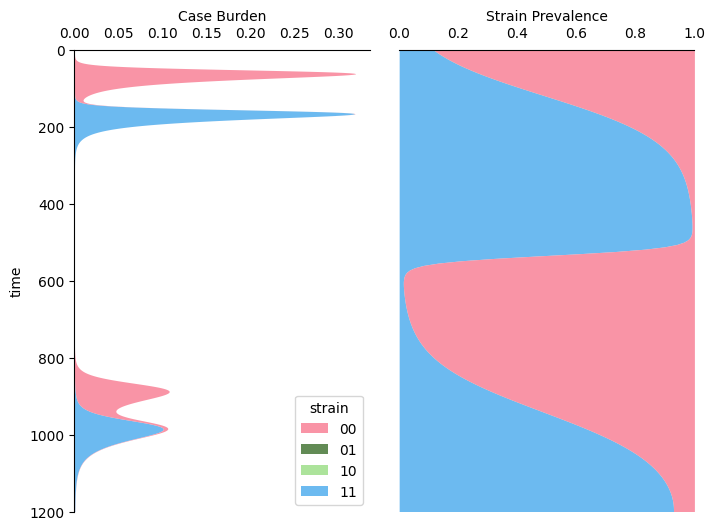

In [ ]:
_base_palette = "husl"
_int_to_color = strain_palette(N_SITES, base_palette=_base_palette)
_strain_palette_map = {
    f"{s:0{N_SITES}b}": _int_to_color[s] for s in _int_to_color
}

_plot_df = long_df.assign(y=-long_df["TIME"])
_plot_df = _plot_df[_plot_df["prevalence"] > 0]

_binwidth = float(raw_df["TIME"].diff().min())

with tp.teed(
    plt.subplots,
    nrows=1,
    ncols=2,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.1},
    teeplot_outattrs={
        "a": "strain-curves",
        "source": "BasicTable2",
        "n_sites": N_SITES,
        "palette": _base_palette,
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    _ax_strain, _ax_kde = _axes

    sns.histplot(
        data=_plot_df,
        y="TIME",
        hue="strain",
        hue_order=strain_cols,
        weights="prevalence",
        binwidth=_binwidth,
        multiple="stack",
        stat="count",
        element="poly",
        palette=_strain_palette_map,
        ax=_ax_strain,
        fill=True,
        linewidth=0,
        legend=True,
    )
    _band_xs = [
        _c.get_paths()[0].vertices[:, 0].max()
        for _c in _ax_strain.collections
        if _c.get_paths()
    ]
    if _band_xs:
        _peak = max(_band_xs)
        _lo, _ = _ax_strain.get_xlim()
        _ax_strain.set_xlim(_lo, _peak * 1.05)

    sns.kdeplot(
        data=_plot_df,
        y="TIME",
        hue="strain",
        hue_order=strain_cols,
        weights="prevalence",
        multiple="fill",
        common_norm=True,
        cut=0,
        palette=_strain_palette_map,
        ax=_ax_kde,
        fill=True,
        linewidth=0,
        legend=False,
        bw_adjust=0.5,
    )

    for _ax in (_ax_strain, _ax_kde):
        _ax.set_xlabel("")
    _ax_kde.set_xlim(0, 1)

    _ax_strain.set_ylabel("time")
    _ax_strain.tick_params(left=True, labelleft=True)
    for _ax in (_ax_strain, _ax_kde):
        _ax.xaxis.tick_top()
        _ax.xaxis.set_label_position("top")
    _ax_kde.tick_params(labelleft=False, left=False)

    sns.despine(ax=_ax_strain, left=False, bottom=True, top=False)
    sns.despine(ax=_ax_kde, left=True, bottom=True, top=False)

    _ax_strain.set_xlabel("Case Burden")
    _ax_kde.set_xlabel("Strain Prevalence")
    _ax_strain.invert_yaxis()

teeplots/2026-05-03-basictable2-strain-curves/a=strain-curves+n_sites=2+palette=rocket+source=BasicTable2+viz=subplots+ext=.pdf
teeplots/2026-05-03-basictable2-strain-curves/a=strain-curves+n_sites=2+palette=rocket+source=BasicTable2+viz=subplots+ext=.png


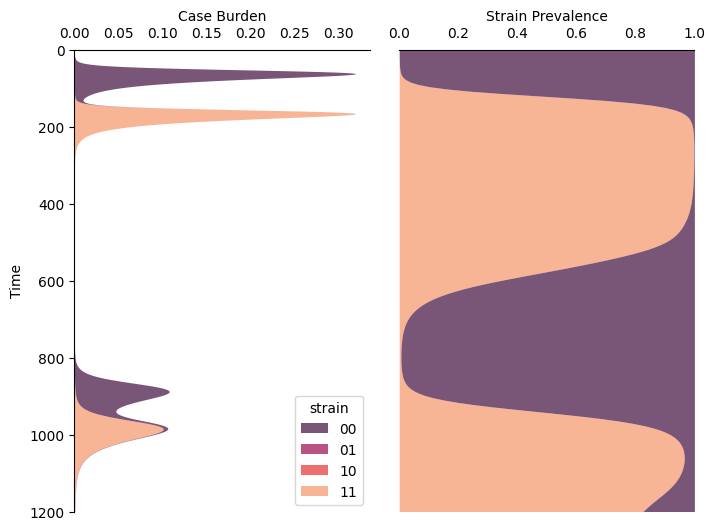

In [ ]:
_base_palette = "husl"
_int_to_color = strain_palette(N_SITES, base_palette=_base_palette)
_strain_palette_map = {
    f"{s:0{N_SITES}b}": _int_to_color[s] for s in _int_to_color
}

_plot_df = long_df.assign(y=long_df["TIME"])
_plot_df = _plot_df[_plot_df["prevalence"] > 0]

_binwidth = float(raw_df["TIME"].diff().min())

with tp.teed(
    plt.subplots,
    nrows=1,
    ncols=2,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.1},
    teeplot_outattrs={
        "a": "strain-curves",
        "source": "BasicTable2",
        "n_sites": N_SITES,
        "palette": "rocket",
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    _ax_strain, _ax_kde = _axes

    sns.histplot(
        data=_plot_df,
        y="y",
        hue="strain",
        hue_order=strain_cols,
        weights="prevalence",
        binwidth=_binwidth,
        multiple="stack",
        stat="count",
        element="poly",
        palette="rocket",
        ax=_ax_strain,
        fill=True,
        linewidth=0,
        legend=True,
    )
    _band_xs = [
        _c.get_paths()[0].vertices[:, 0].max()
        for _c in _ax_strain.collections
        if _c.get_paths()
    ]
    if _band_xs:
        _peak = max(_band_xs)
        _lo, _ = _ax_strain.get_xlim()
        _ax_strain.set_xlim(_lo, _peak * 1.05)

    sns.kdeplot(
        data=_plot_df,
        y="y",
        hue="strain",
        hue_order=strain_cols,
        weights="prevalence",
        multiple="fill",
        common_norm=True,
        cut=0,
        palette="rocket",
        ax=_ax_kde,
        fill=True,
        linewidth=0,
        legend=False,
        bw_adjust=0.2,
    )

    for _ax in (_ax_strain, _ax_kde):
        _ax.set_xlabel("")
    _ax_kde.set_xlim(0, 1)

    _ax_strain.set_ylabel("Time")
    _ax_strain.tick_params(left=True, labelleft=True)
    for _ax in (_ax_strain, _ax_kde):
        _ax.xaxis.tick_top()
        _ax.xaxis.set_label_position("top")
    _ax_kde.tick_params(labelleft=False, left=False)

    sns.despine(ax=_ax_strain, left=False, bottom=True, top=False)
    sns.despine(ax=_ax_kde, left=True, bottom=True, top=False)

    _ax_strain.set_xlabel("Case Burden")
    _ax_kde.set_xlabel("Strain Prevalence")
    _ax_strain.invert_yaxis()

## Per-Allele Prevalence Plots

Same stacked-histplot + filled-KDE pair as the per-strain plot, but
aggregated by individual allele: at each time, the prevalence of
"site `s`, allele `a`" is the sum of strain prevalences over the
two strains carrying allele `a` at site `s`. Each site gets its own
hue (ggplot-style HCL via `husl`); the two alleles within a site
are distinguished by lightness (allele 0 darker, allele 1 lighter).

`BasicTable2.xlsx` does not provide per-allele susceptibility, so
only prevalence is rendered here.

teeplots/2026-05-03-basictable2-strain-curves/a=allele-curves+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.pdf
teeplots/2026-05-03-basictable2-strain-curves/a=allele-curves+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.png


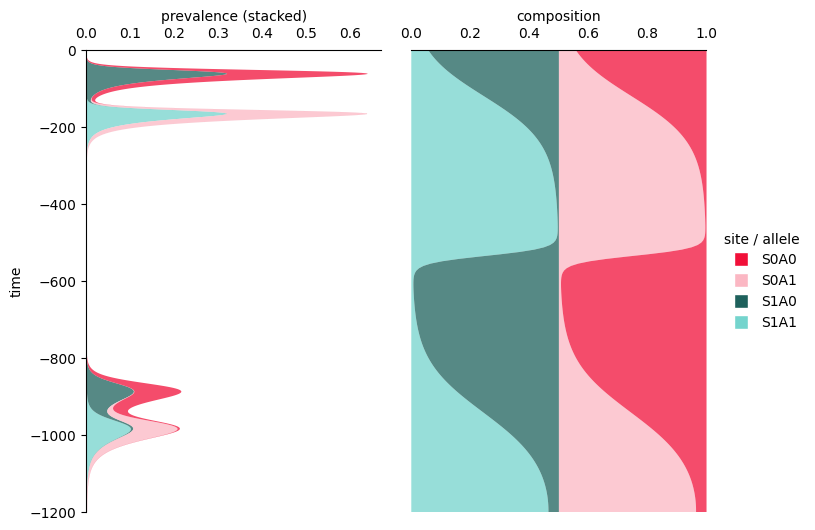

In [ ]:
_base_palette = "husl"
_site_allele_to_color = allele_palette(N_SITES, base_palette=_base_palette)
_allele_palette_map = {
    f"S{site}A{allele}": _site_allele_to_color[(site, allele)]
    for site in range(N_SITES)
    for allele in (0, 1)
}

_plot_df = allele_long_df.assign(y=-allele_long_df["TIME"])
_plot_df = _plot_df[_plot_df["prevalence"] > 0]
_binwidth = float(raw_df["TIME"].diff().min())

with tp.teed(
    plt.subplots,
    nrows=1,
    ncols=2,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.1},
    teeplot_outattrs={
        "a": "allele-curves",
        "source": "BasicTable2",
        "n_sites": N_SITES,
        "palette": _base_palette,
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    _ax_count, _ax_kde = _axes

    sns.histplot(
        data=_plot_df,
        y="y",
        hue="label",
        hue_order=allele_labels,
        weights="prevalence",
        binwidth=_binwidth,
        multiple="stack",
        stat="count",
        element="poly",
        palette=_allele_palette_map,
        ax=_ax_count,
        fill=True,
        linewidth=0,
        legend=False,
    )

    sns.kdeplot(
        data=_plot_df,
        y="y",
        hue="label",
        hue_order=allele_labels,
        weights="prevalence",
        multiple="fill",
        common_norm=True,
        cut=0,
        palette=_allele_palette_map,
        ax=_ax_kde,
        fill=True,
        linewidth=0,
        legend=False,
        bw_adjust=0.5,
    )

    for _ax in (_ax_count, _ax_kde):
        _ax.set_xlabel("")
    _ax_kde.set_xlim(0, 1)

    _ax_count.set_ylabel("time")
    _ax_count.tick_params(left=True, labelleft=True)
    for _ax in (_ax_count, _ax_kde):
        _ax.xaxis.tick_top()
        _ax.xaxis.set_label_position("top")
    _ax_kde.tick_params(labelleft=False, left=False)

    sns.despine(ax=_ax_count, left=False, bottom=True, top=False)
    sns.despine(ax=_ax_kde, left=True, bottom=True, top=False)

    _ax_count.set_xlabel("prevalence (stacked)")
    _ax_kde.set_xlabel("composition")

    def _allele_handle(label):
        return plt.Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor=_allele_palette_map[label],
            markersize=10,
            label=label,
        )

    _ax_kde.legend(
        handles=[_allele_handle(label) for label in allele_labels],
        title="site / allele",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handletextpad=0.4,
    )

## Twiny Line-Plot Variants

Two-panel figure (vertically stacked, sharing the time x-axis) for
each grouping: top panel reserved for population susceptibility
(`BasicTable2.xlsx` does not provide it, so the panel is left blank
with a note); bottom panel renders the prevalence curves as solid
lines. Susceptibilities would be drawn dashed in the same color as
their matching prevalence curves once data becomes available.

teeplots/2026-05-03-basictable2-strain-curves/a=strain-twiny+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.pdf
teeplots/2026-05-03-basictable2-strain-curves/a=strain-twiny+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.png


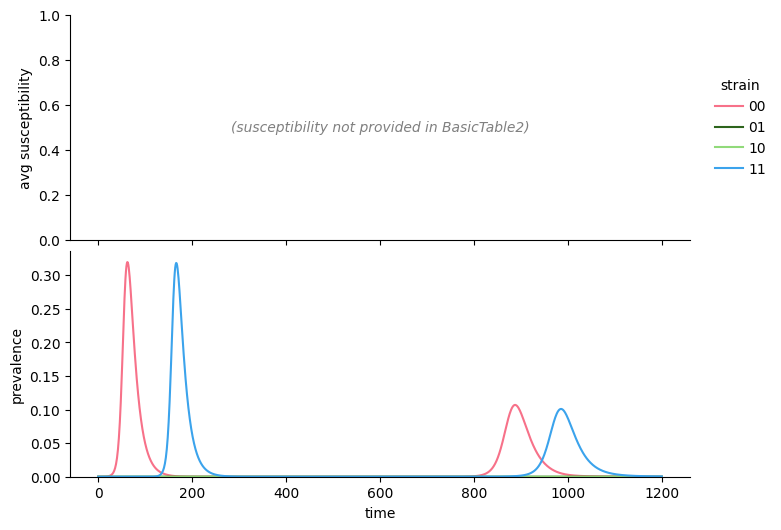

In [ ]:
_base_palette = "husl"
_int_to_color = strain_palette(N_SITES, base_palette=_base_palette)
_strain_palette_map_t = {
    f"{s:0{N_SITES}b}": _int_to_color[s] for s in _int_to_color
}

with tp.teed(
    plt.subplots,
    nrows=2,
    ncols=1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"hspace": 0.05},
    teeplot_outattrs={
        "a": "strain-twiny",
        "source": "BasicTable2",
        "n_sites": N_SITES,
        "palette": _base_palette,
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    _ax_susc, _ax_prev = _axes

    _ax_susc.text(
        0.5,
        0.5,
        "(susceptibility not provided in BasicTable2)",
        ha="center",
        va="center",
        transform=_ax_susc.transAxes,
        fontsize=10,
        color="gray",
        style="italic",
    )
    _ax_susc.set_ylabel("avg susceptibility")
    _ax_susc.set_ylim(0.0, 1.0)

    for _s in strain_cols:
        _ax_prev.plot(
            raw_df["TIME"].to_numpy(),
            raw_df[_s].to_numpy(),
            color=_strain_palette_map_t[_s],
            linestyle="-",
            linewidth=1.5,
            label=_s,
        )

    _ax_prev.set_ylabel("prevalence")
    _ax_prev.set_xlabel("time")
    _ax_prev.set_ylim(bottom=0.0)

    _ax_susc.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                color=_strain_palette_map_t[_s],
                lw=1.5,
                label=_s,
            )
            for _s in strain_cols
        ],
        title="strain",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handletextpad=0.4,
    )
    sns.despine(ax=_ax_susc)
    sns.despine(ax=_ax_prev)

teeplots/2026-05-03-basictable2-strain-curves/a=allele-twiny+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.pdf
teeplots/2026-05-03-basictable2-strain-curves/a=allele-twiny+n_sites=2+palette=husl+source=BasicTable2+viz=subplots+ext=.png


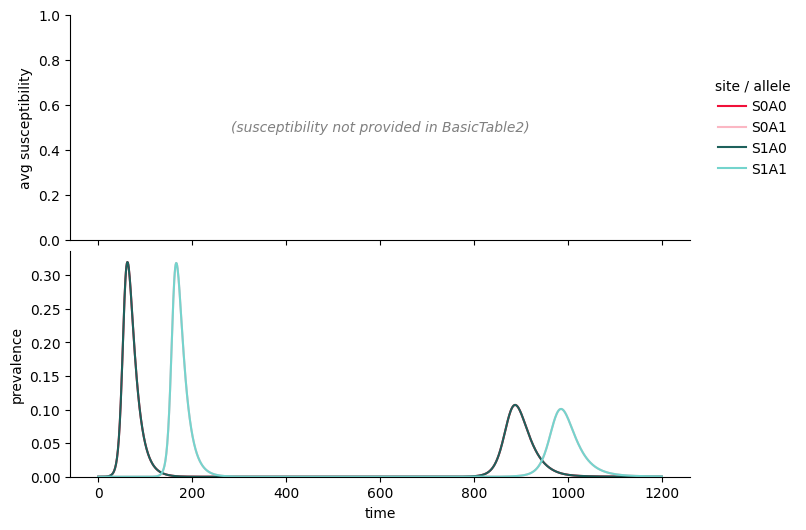

In [ ]:
_base_palette = "husl"
_site_allele_to_color = allele_palette(N_SITES, base_palette=_base_palette)
_allele_palette_map_t = {
    f"S{site}A{allele}": _site_allele_to_color[(site, allele)]
    for site in range(N_SITES)
    for allele in (0, 1)
}

with tp.teed(
    plt.subplots,
    nrows=2,
    ncols=1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"hspace": 0.05},
    teeplot_outattrs={
        "a": "allele-twiny",
        "source": "BasicTable2",
        "n_sites": N_SITES,
        "palette": _base_palette,
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    _ax_susc, _ax_prev = _axes

    _ax_susc.text(
        0.5,
        0.5,
        "(susceptibility not provided in BasicTable2)",
        ha="center",
        va="center",
        transform=_ax_susc.transAxes,
        fontsize=10,
        color="gray",
        style="italic",
    )
    _ax_susc.set_ylabel("avg susceptibility")
    _ax_susc.set_ylim(0.0, 1.0)

    for _label in allele_labels:
        _sub = allele_long_df[allele_long_df["label"] == _label]
        _sub = _sub.sort_values("TIME")
        _ax_prev.plot(
            _sub["TIME"].to_numpy(),
            _sub["prevalence"].to_numpy(),
            color=_allele_palette_map_t[_label],
            linestyle="-",
            linewidth=1.5,
            label=_label,
        )

    _ax_prev.set_ylabel("prevalence")
    _ax_prev.set_xlabel("time")
    _ax_prev.set_ylim(bottom=0.0)

    _ax_susc.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                color=_allele_palette_map_t[_label],
                lw=1.5,
                label=_label,
            )
            for _label in allele_labels
        ],
        title="site / allele",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handletextpad=0.4,
    )
    sns.despine(ax=_ax_susc)
    sns.despine(ax=_ax_prev)